## Análisis y Preprocesamiento de los Datos

Vamos a trabajar con un dataset de caracteres japoneses, similar al clásico MNIST, compuesto por imágenes en escala de grises de 28 × 28 píxeles. En total, hay 49 clases posibles, correspondientes a diferentes caracteres.

Primero, cargamos los datos almacenados en archivos `.npy`. Luego, visualizamos algunas imágenes para familiarizarnos con el contenido y asegurarnos de que se han cargado correctamente. Para esto, convertimos los vectores planos en matrices de 28x28.

A continuación, dividimos el conjunto en tres subconjuntos: entrenamiento, validación y prueba. También normalizamos los valores de las imágenes dividiendo por 255, de modo que queden en el rango [0, 1].

Finalmente, como nuestra red neuronal usará la función softmax en la capa de salida, codficamos las etiquetas (`y`) usando one-hot encoding.

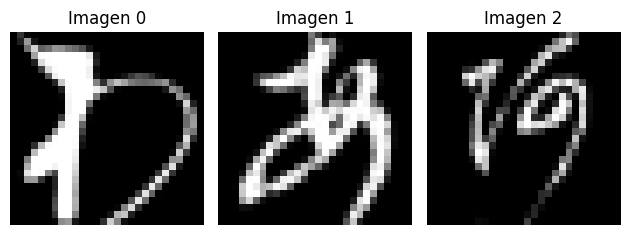

In [1]:
from src.preprocessing import train_test_split, one_hot
from src.visualization import plot_images
import numpy as np

X_images = np.load("Data/X_images.npy")
y_images = np.load("Data/y_images.npy")

plot_images(X_images, 3)
X_images = X_images / 255

X_dev, y_dev, X_test, y_test = train_test_split(X_images, y_images, test_size=0.2)
X_train, y_train, X_val, y_val = train_test_split(X_dev, y_dev, test_size=0.25)

num_classes = len(np.unique(y_images))
y_train = one_hot(y_train, num_classes)
y_val = one_hot(y_val, num_classes)
y_test = one_hot(y_test, num_classes)

# Transponer X (features x muestras)
X_train = X_train.T
X_val = X_val.T

## Implementacion de modelo inicial

Implementamos una red neuronal desde cero, con soporte para múltiples capas ocultas y clasificación multiclase. Cada capa oculta utiliza la función de activación **`ReLU`**, mientras que la capa de salida emplea **`softmax`** para generar una distribución de probabilidad sobre las clases posibles.

El entrenamiento se lleva a cabo mediante **`backpropagation`**, adaptado específicamente para el caso *softmax + cross-entropy*, utilizando **`descenso por gradiente estándar`**. La función de costo utilizada es la **`entropía cruzada`**, adecuada para problemas de clasificación.

En esta instancia, definimos y entrenamos un modelo con dos capas ocultas: la primera con **100 nodos**, y la segunda con **80**. A este modelo lo denominamos **`M0`**.

Al finalizar el entrenamiento, graficamos la evolución de la función de costo (**cross-entropy**) sobre los conjuntos de **entrenamiento** y **validación** a lo largo de las épocas, con el objetivo de evaluar el desempeño del modelo.

Epoch 0, Train Loss: 3.8075, Val Loss: 3.8170
Epoch 50, Train Loss: 1.4968, Val Loss: 2.0503
Epoch 100, Train Loss: 1.0365, Val Loss: 1.9356
Epoch 150, Train Loss: 0.2856, Val Loss: 1.8078
Epoch 200, Train Loss: 0.0587, Val Loss: 1.7494
Epoch 250, Train Loss: 0.0311, Val Loss: 1.8717
Epoch 300, Train Loss: 0.0199, Val Loss: 1.9598
Epoch 350, Train Loss: 0.0142, Val Loss: 2.0277
Epoch 400, Train Loss: 0.0108, Val Loss: 2.0822
Epoch 450, Train Loss: 0.0086, Val Loss: 2.1285


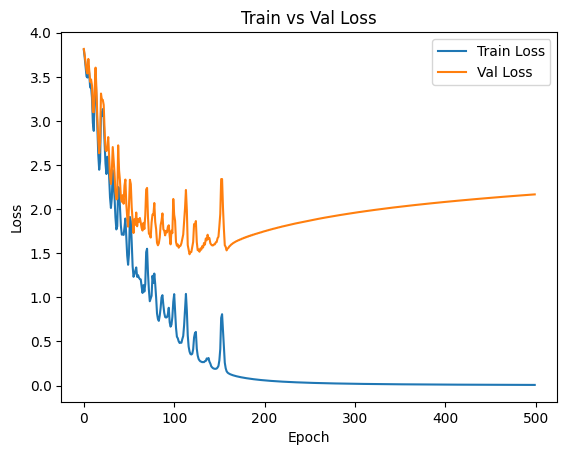

In [2]:
from src.models import RedNeuronal

m0 = RedNeuronal(X_train.shape[0], [100, 80], num_classes, lr=1)
m0.train(X_train, y_train, show_progress=True, X_val=X_val, Y_val=y_val)

Durante el entrenamiento observamos que la función de costo en el conjunto de entrenamiento continuó disminuyendo de forma sostenida, mientras que la pérdida en el conjunto de validación dejó de mejorar relativamente temprano y comenzó a aumentar de manera progresiva. Este comportamiento es indicativo de **`overfitting`**, donde el modelo se ajusta demasiado a los datos de entrenamiento y pierde capacidad de generalización.

Para finalizar el análisis del modelo **`M0`**, evaluamos su desempeño sobre el conjunto de validación a través de tres métricas clave:

- **`Accuracy`**, para medir la proporción de predicciones correctas.
- **`Cross-Entropy`**, como función de costo utilizada también durante el entrenamiento.
- **`Matriz de confusión`**, que nos permite examinar en detalle cómo se distribuyen los errores entre las distintas clases.

Entrenamiento:
 - Accuracy: 1.00
 - Loss: 0.01

Validación:
 - Accuracy: 0.62
 - Loss: 2.17


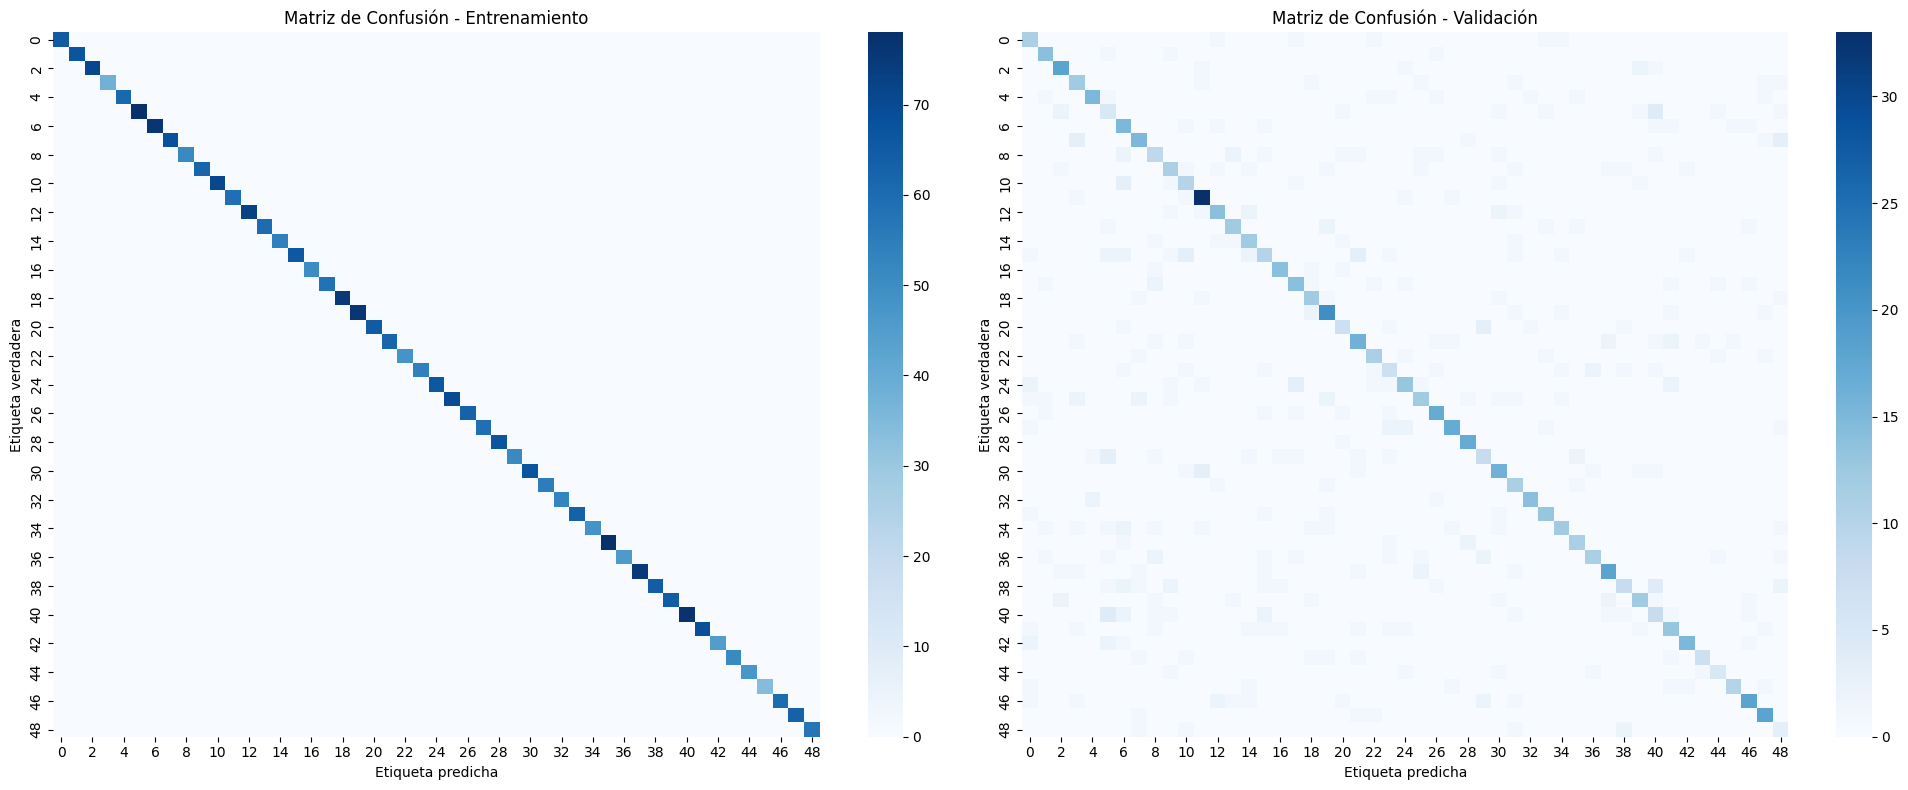

In [3]:
from src.visualization import show_metrics_and_matrices
show_metrics_and_matrices(m0, X_train, y_train, X_val, y_val)

Los resultados obtenidos para el modelo **M0** reflejan un entrenamiento exitoso sobre el conjunto de entrenamiento, con una **accuracy de 1.00** y una **pérdida (loss) muy baja**. Sin embargo, en validación el rendimiento cae significativamente, con una **accuracy de al rededor del 60%** y una **pérdida de +2**, lo cual confirma la presencia de **`overfitting severo`**: el modelo logra memorizar los datos de entrenamiento pero no generaliza adecuadamente.

A continuación, buscamos mejorar este comportamiento implementando una serie de técnicas de entrenamiento avanzadas. Para cada optimización, evaluamos su impacto sobre el rendimiento y el tiempo de entrenamiento del modelo.

Las mejoras implementadas fueron:

- **`Rate scheduling`**, tanto **lineal (con saturación)** como **exponencial**, para modificar dinámicamente la tasa de aprendizaje durante el entrenamiento.
- **`Mini-batch stochastic gradient descent`**, que reemplaza el gradiente descendiente estándar por uno más eficiente y estable.
- **`Optimizador ADAM`**, que ajusta de forma adaptativa las tasas de aprendizaje para cada parámetro.
- **`Regularización L2`**, para penalizar los pesos grandes y reducir el riesgo de overfitting.
- **`Early stopping`**, aplicado en todos los experimentos para evitar entrenar durante más épocas de las necesarias.
- **`Dropout`**, como técnica adicional de regularización, no incluida en esta etapa.

Cada una de estas optimizaciones fue evaluada **de manera aislada**, manteniendo constante el resto de la arquitectura y los hiperparámetros, con el fin de identificar su efecto puntual. Los resultados incluyen métricas de **accuracy y loss** sobre los conjuntos de **entrenamiento y validación**, así como el **tiempo de entrenamiento** en cada caso, los cuales se resumen en la tabla siguiente.


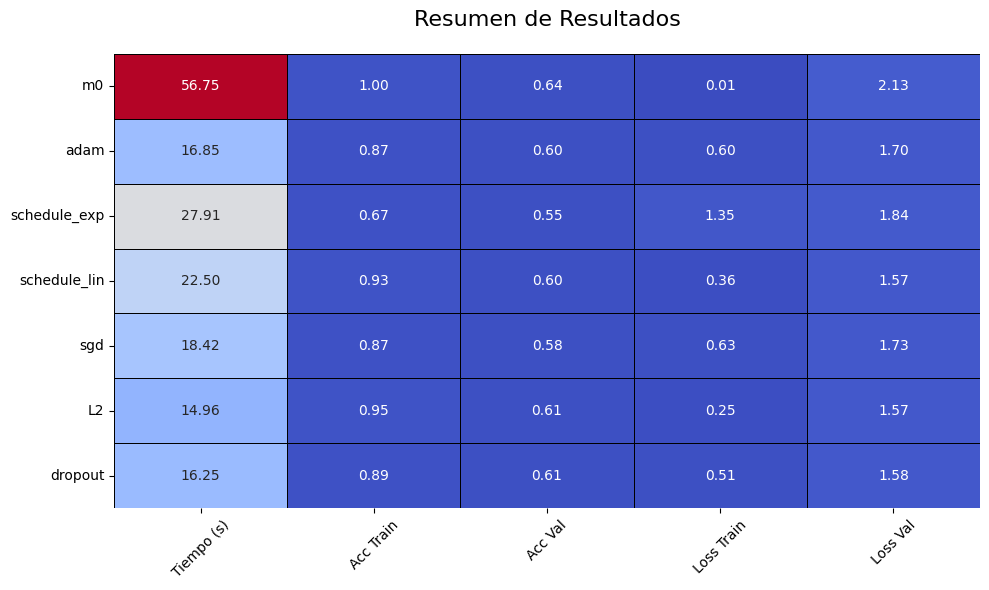

In [4]:
from src.evaluation import evaluate_training_techniques 
from src.visualization import display_results
results = evaluate_training_techniques(X_train, y_train, X_val, y_val)
display_results(results)


A partir de los resultados obtenidos, observamos varios patrones clave en el impacto de las optimizaciones:
- El **`early stopping`** reduce significativamente el tiempo que requiere entrenar los modelos
- Las estrategias de **`rate scheduling`** muestran comportamientos contrastantes:  
  - El esquema **lineal** mantiene una **alta accuracy comparable al modelo base**, pero logra **mejorar notablemente la pérdida**, siendo una mejora efectiva.  
  - En cambio, el esquema **exponencial** **reduce la accuracy y eleva el tiempo de entrenamiento**, sin ofrecer mejoras significativas en la pérdida, por lo que resulta poco conveniente.

- Los **optimizadores** **`Adam`** y **`SGD`** permiten una **convergencia mucho más rápida**, y presentan una **mejora clara en la pérdida de validación**. Sin embargo, **no superan al modelo base en accuracy**, lo que sugiere una posible pérdida de capacidad de generalización.

- Las técnicas de **`regularización`**, como **L2** y **dropout**, logran **reducir el sobreajuste**, mejorando la **loss de validación**. **Dropout** es ligeramente más lento que L2, pero ambos resultan efectivos sin afectar demasiado la accuracy.

Teniendo en cuenta estos resultados, el próximo paso es **`explorar combinaciones`** entre las estrategias más prometedoras junto con ajustes en la arquitectura de la red. El objetivo es reducir la **pérdida en validación**, manteniendo buena generalización y tiempos razonables.

El nuevo modelo obtenido se denominará **`M1`**.

Mejor modelo (acc val=1.47):
{'lr': 1, 'L2': 0.01, 'solver': 'gd', 'dropout': 0, 'hidden': [256, 128], 'batch_size': 3000}
Entrenamiento:
 - Accuracy: 0.96
 - Loss: 0.24

Validación:
 - Accuracy: 0.64
 - Loss: 1.47


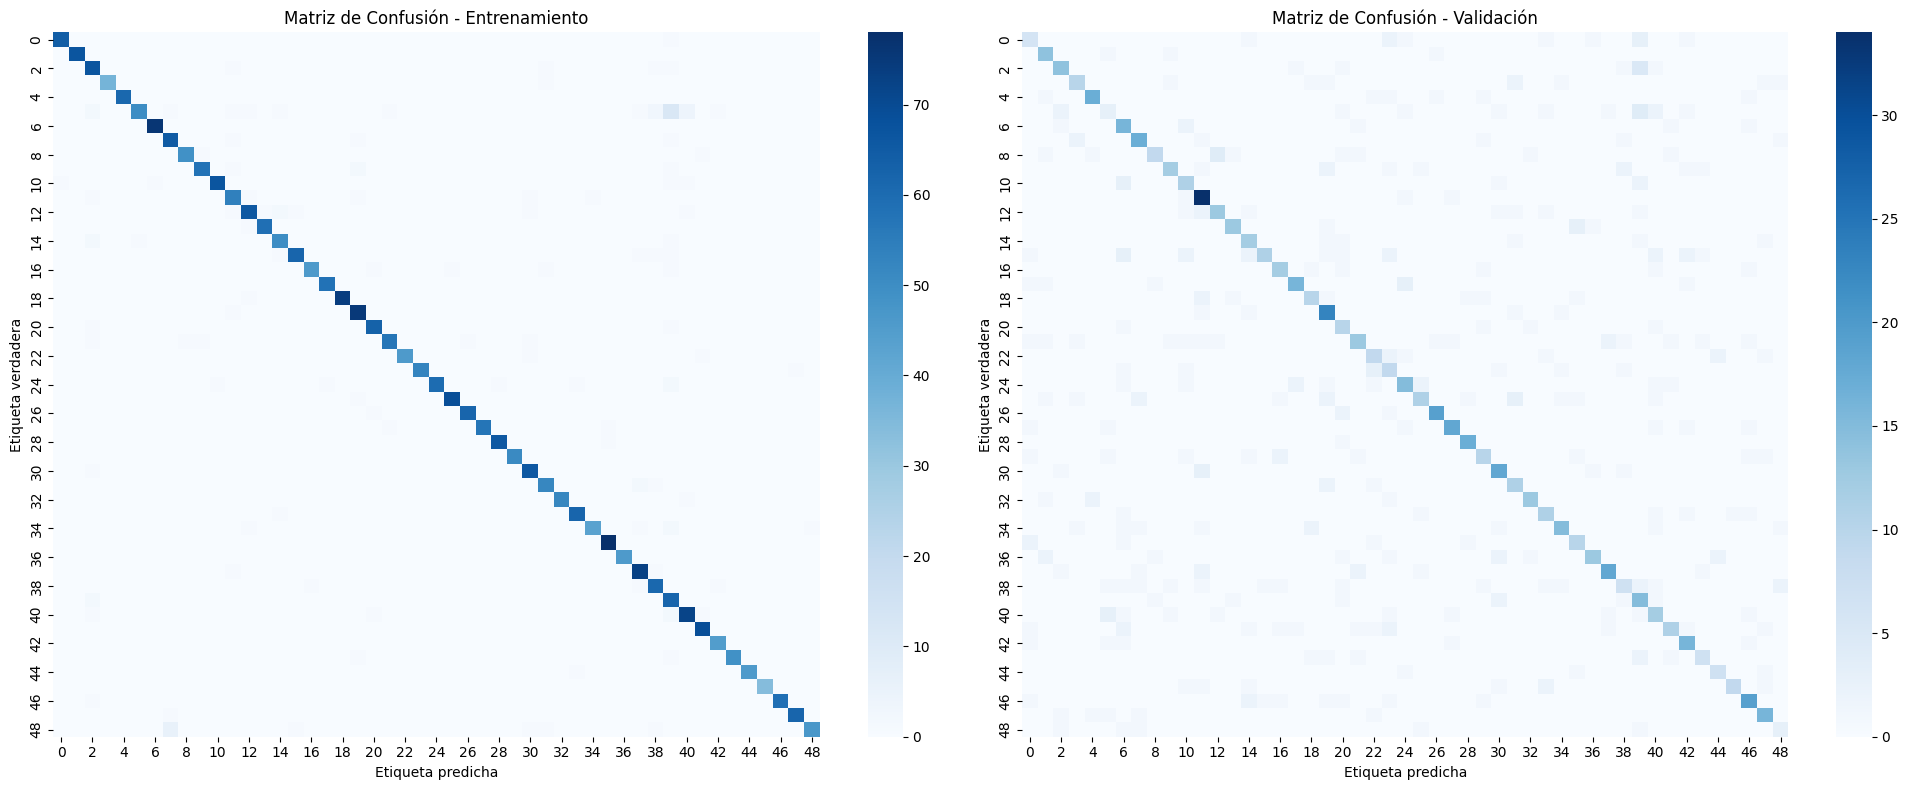

In [5]:
from src.evaluation import find_best_model
m1 = find_best_model(X_train, y_train, X_val, y_val)
show_metrics_and_matrices(m1, X_train, y_train, X_val, y_val)

Luego de evaluar múltiples combinaciones de arquitecturas e hiperparámetros, determinamos que el mejor rendimiento se logra con una red de arquitectura **256-128**, entrenada con **learning rate = 1**, optimizador **GD (gradiente descendente estándar)**, **sin dropout**, y una **regularización L2 de 0.01**.  
Este resultado muestra que, en este caso, una arquitectura moderadamente profunda junto con una regularización suave y un esquema de optimización simple logran el mejor equilibrio entre precisión y capacidad de generalización. Sorprendentemente, técnicas más complejas como ADAM o dropout no superaron este enfoque directo.

A partir de esta configuración óptima, desarrollamos ahora una nueva red utilizando **`PyTorch`**, replicando tanto la arquitectura como los hiperparámetros hallados. Este nuevo modelo será denominado **`M2`**.

Epoch 1: Val Loss = 3.7756
Epoch 51: Val Loss = 2.5687
Epoch 101: Val Loss = 1.7579
Epoch 151: Val Loss = 1.9151
Epoch 201: Val Loss = 1.7890
Epoch 251: Val Loss = 1.6460
Epoch 301: Val Loss = 1.6648
Epoch 351: Val Loss = 1.7534
Epoch 401: Val Loss = 1.5626
Epoch 451: Val Loss = 1.5575
Early stopping.
Entrenamiento:
 - Accuracy: 0.81
 - Loss: 0.84

Validación:
 - Accuracy: 0.59
 - Loss: 1.52


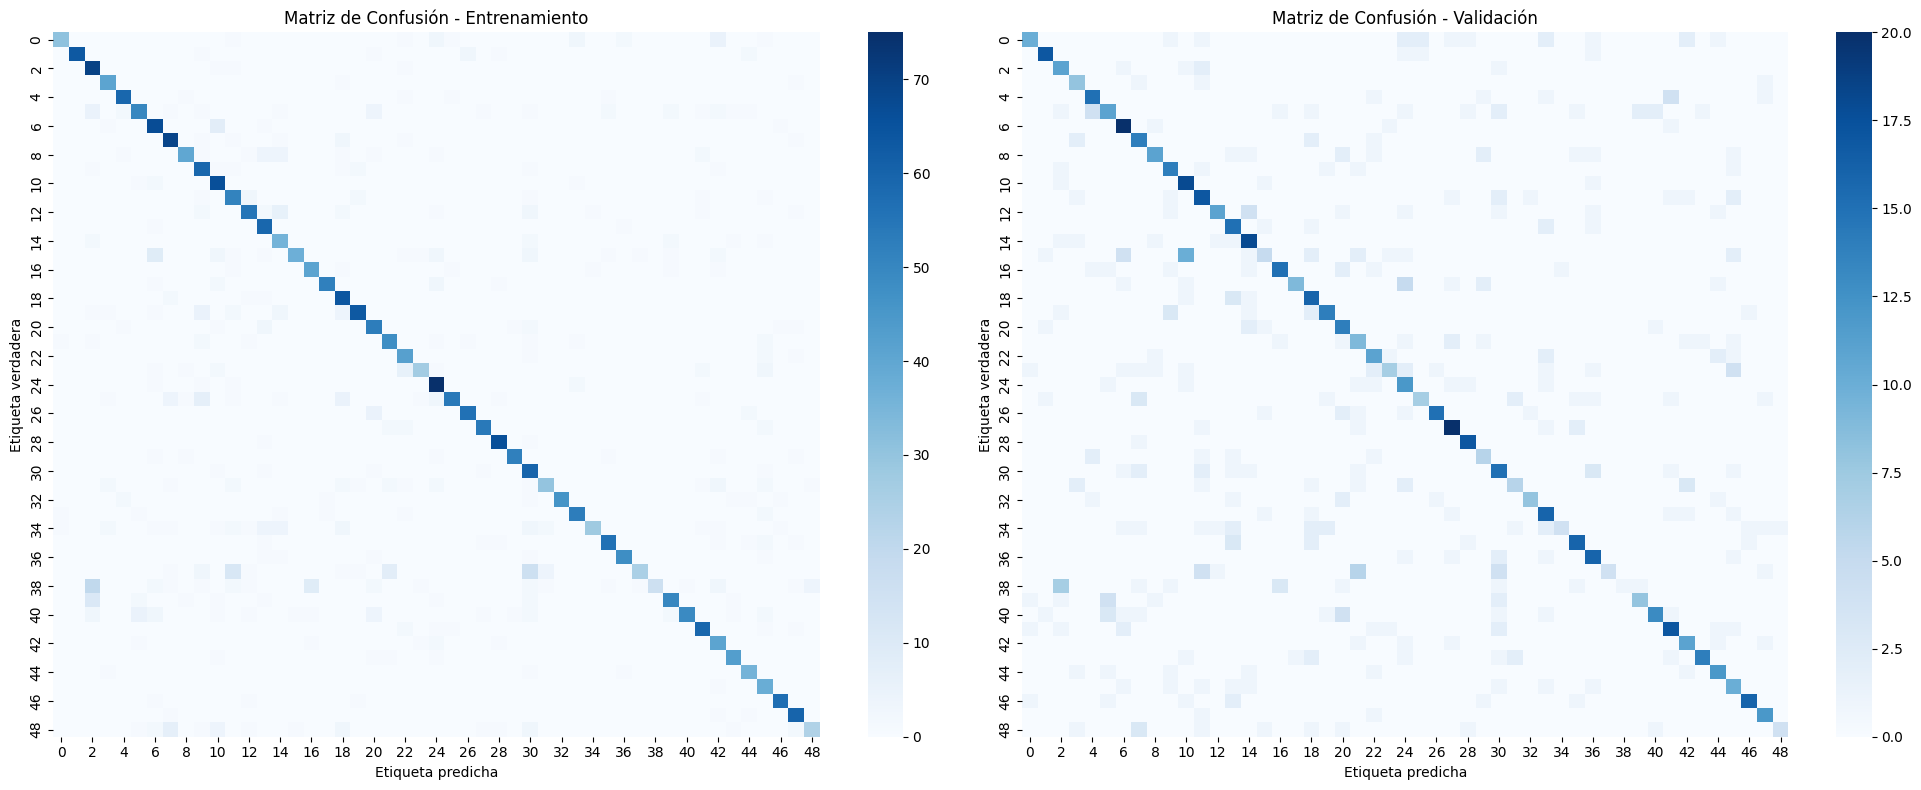

In [6]:
from src.visualization import show_torch_metrics_and_matrices
from src.preprocessing import train_test_split
from src.models import TorchNeuralNet
import torch

# Split
X_dev, y_dev, X_testpy, y_testpy = train_test_split(X_images, y_images, test_size=0.2)
X_trainpy, y_trainpy, X_valpy, y_valpy = train_test_split(X_dev, y_dev, test_size=0.25)

# Modelo
model2 = TorchNeuralNet(784, [256, 128], 49, lr=1, L2=0.01)
X_valpy = torch.from_numpy(X_valpy).float()  # Convierte a tensor de tipo float32
y_valpy = torch.from_numpy(y_valpy).long()   # Convierte a tensor de enteros largos (para etiquetas)

model2.train_model(X_trainpy, y_trainpy,
                  epochs=500,
                  batch_size=3000,
                  X_val=X_valpy, Y_val=y_valpy,
                  early_stopping=True,
                  patience=100,
                  show_progress=True)
show_torch_metrics_and_matrices(model2, X_trainpy, y_trainpy, X_valpy, y_valpy)

Luego de haber identificado la mejor configuración arquitectónica y de entrenamiento en nuestra implementación propia (`M1`), procedimos a replicar dicha configuración utilizando la librería **PyTorch**, con el objetivo de evaluar si los resultados se mantenían o incluso mejoraban al aprovechar las capacidades de esta herramienta de alto nivel. Esta nueva versión del modelo fue denominada **`M2`**.

En términos de desempeño, el modelo `M2` logró una precisión de entrenamiento razonable, aunque **ligeramente inferior** al modelo `M1`. En el conjunto de validación, la performance fue **similar pero algo menos favorable**, lo que sugiere que la implementación en PyTorch no introdujo mejoras significativas en la capacidad de generalización con esta configuración específica.

Esto refuerza la solidez de los hiperparámetros seleccionados previamente, aunque también muestra que la ventaja de PyTorch puede depender más del diseño de arquitecturas avanzadas o del uso de técnicas específicas que no estaban presentes en esta configuración base.

A continuación, **exploraremos variantes en la arquitectura del modelo**, modificando la **cantidad de capas ocultas** y la **cantidad de unidades por capa**. Se evaluarán configuraciones con capas más grandes, más pequeñas, y distintas profundidades (entre 1 y 4 capas). El objetivo es determinar qué combinación ofrece el mejor desempeño posible. Esta nueva etapa de experimentación dará lugar al modelo **`M3`**.


[M3] Mejor generalización: [1024], Val Loss = 1.5299
Entrenamiento:
 - Accuracy: 0.86
 - Loss: 0.82

Validación:
 - Accuracy: 0.61
 - Loss: 1.53


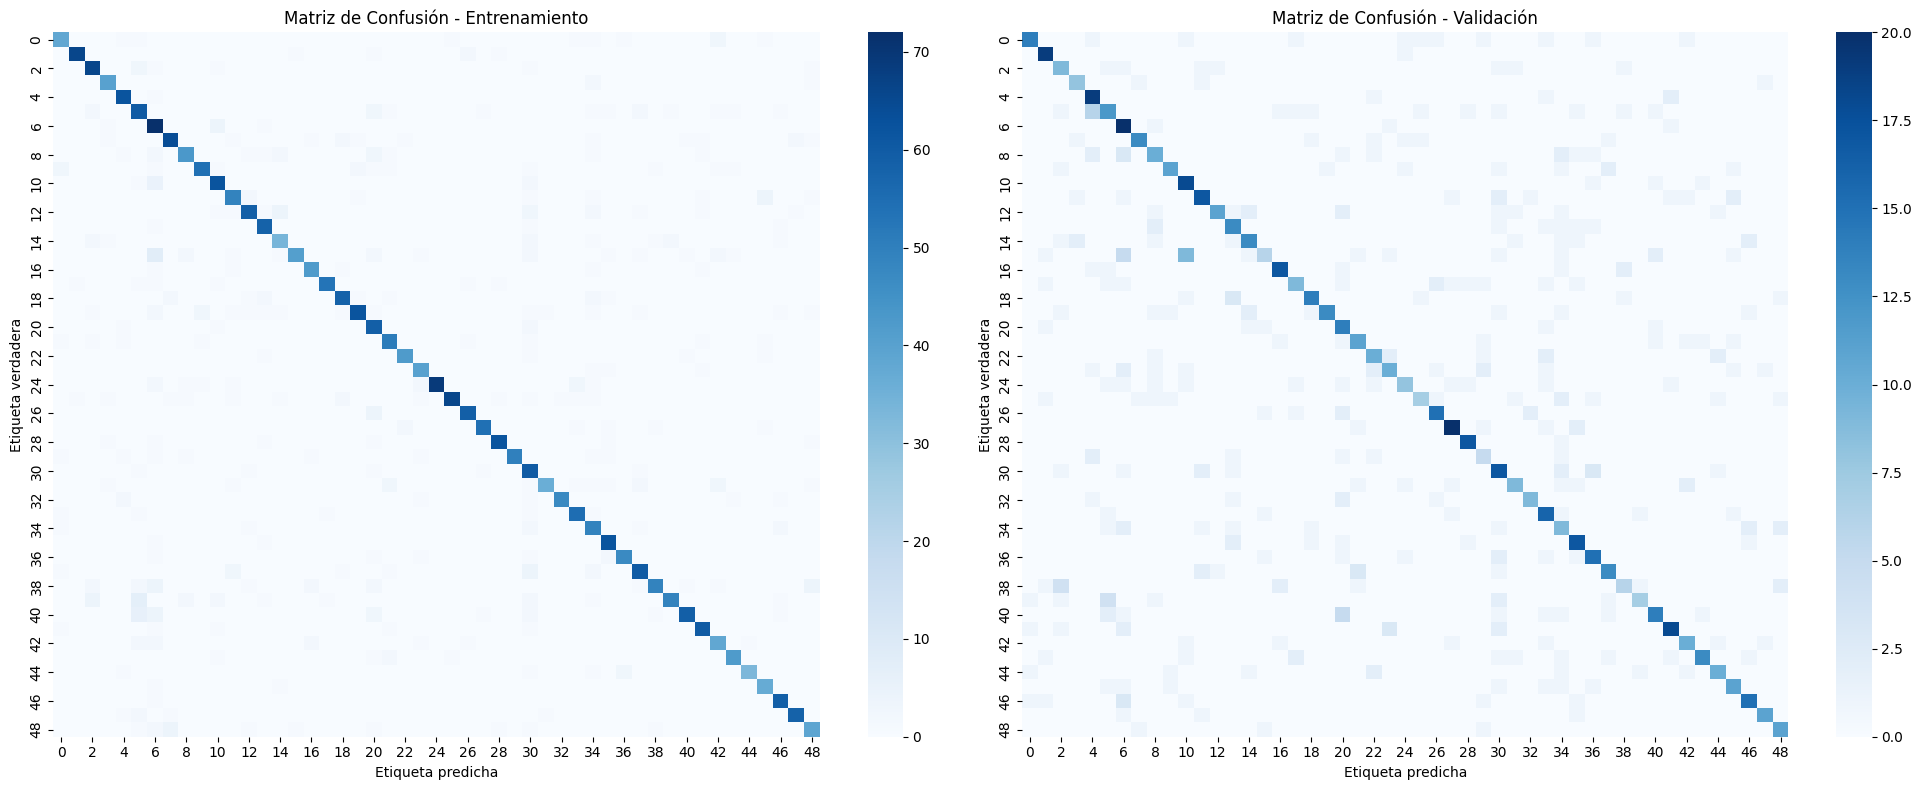

In [7]:
from src.evaluation import find_M3_model

# Búsqueda del modelo M3 (generalización)
model3, M3_config, M3_val_loss = find_M3_model(
    X_trainpy, y_trainpy, X_valpy, y_valpy,
    hidden_layer_options=[[64], [128], [256], [512], [1024], [128, 64], [256, 128], [128, 64, 32], [512, 256, 128], [256, 128, 64], [512, 256, 128, 64]],
    input_dim=784, output_dim=49, epochs=500, batch_size=3000, lr=1, L2=0.01, patience=50, show_progress=False
)

show_torch_metrics_and_matrices(model3, X_trainpy, y_trainpy, X_valpy, y_valpy)

El modelo `M3`, resultado de explorar múltiples combinaciones de capas ocultas y unidades por capa, logró su mejor desempeño con una arquitectura de **una única capa oculta de 1024 unidades**. Esta configuración mostró la mejor capacidad de generalización dentro del espacio explorado.

Sin embargo, observamos que el rendimiento parece haberse **estancado**, y que **no hay mucho margen de mejora** adicional con este enfoque, ya que las variaciones en profundidad y tamaño no produjeron avances significativos.

Como siguiente paso, vamos a utilizar **PyTorch** para construir una arquitectura con mayor capacidad, buscando forzar un caso claro de **overfitting**. Esto nos permitirá estudiar más a fondo los límites del modelo y sus patrones de generalización. Esta nueva versión será denominada **`M4`**.


[M4] Más overfitting: [512, 256, 128, 64], Train Loss = 0.0011
Entrenamiento:
 - Accuracy: 1.00
 - Loss: 0.00

Validación:
 - Accuracy: 0.62
 - Loss: 2.87


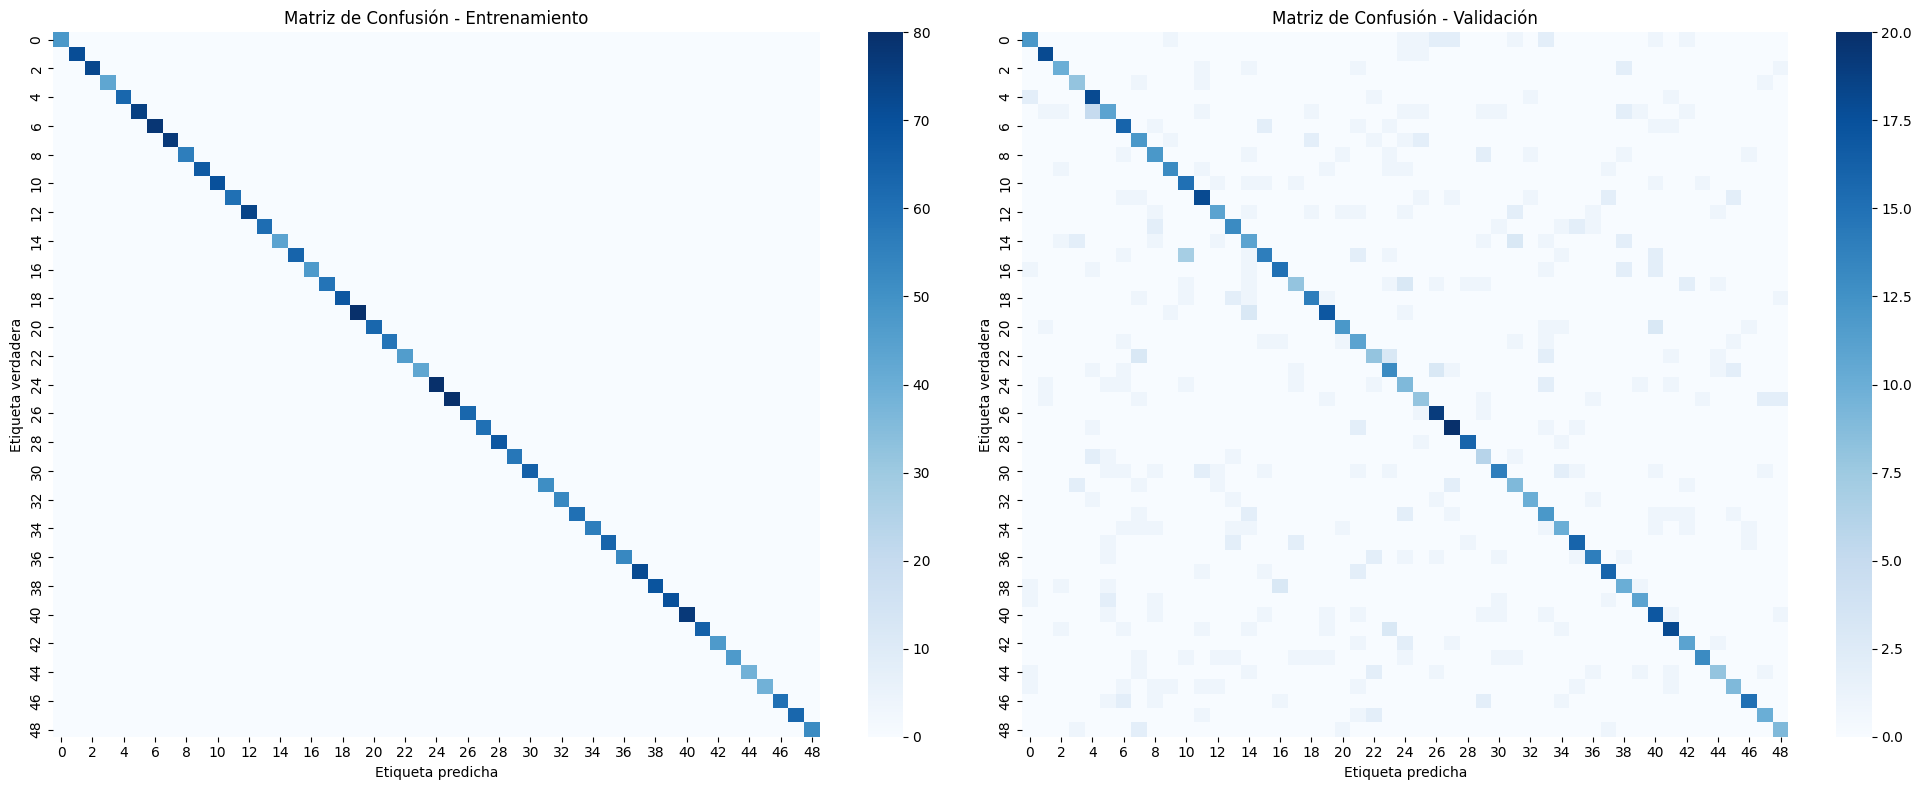

In [8]:
from src.evaluation import find_M4_model

# Búsqueda del modelo M4 (sobreajuste máximo)
model4, M4_config, M4_train_loss = find_M4_model(
    X_trainpy, y_trainpy,
    hidden_layer_options=[[64], [128], [256], [512], [1024], [128, 64], [256, 128], [128, 64, 32], [512, 256, 128], [256, 128, 64], [512, 256, 128, 64]],
    input_dim=784, output_dim=49, epochs=500, batch_size=3000, lr=1, show_progress=False
)
show_torch_metrics_and_matrices(model4, X_trainpy, y_trainpy, X_valpy, y_valpy)

El modelo `M4` quedo diseñado con una arquitectura de **cuatro capas ocultas** de tamaño decreciente, y se observa un caso claro de **overfitting**. Como se esperaba, el modelo alcanzó una precisión perfecta en entrenamiento, pero con una pérdida significativamente mayor en validación, lo que evidencia una baja capacidad de generalización.

Como siguiente paso, vamos a **comparar la performance sobre el conjunto de test** de los cinco modelos desarrollados hasta el momento: `M0`, `M1`, `M2`, `M3` y `M4`.

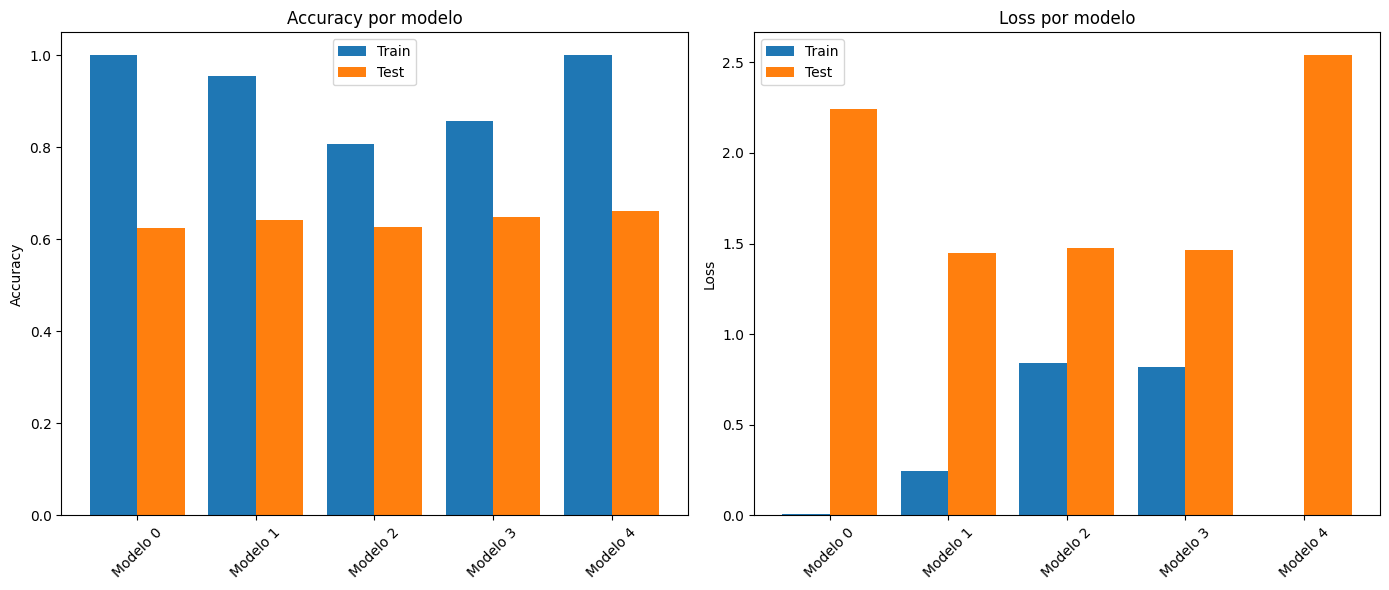

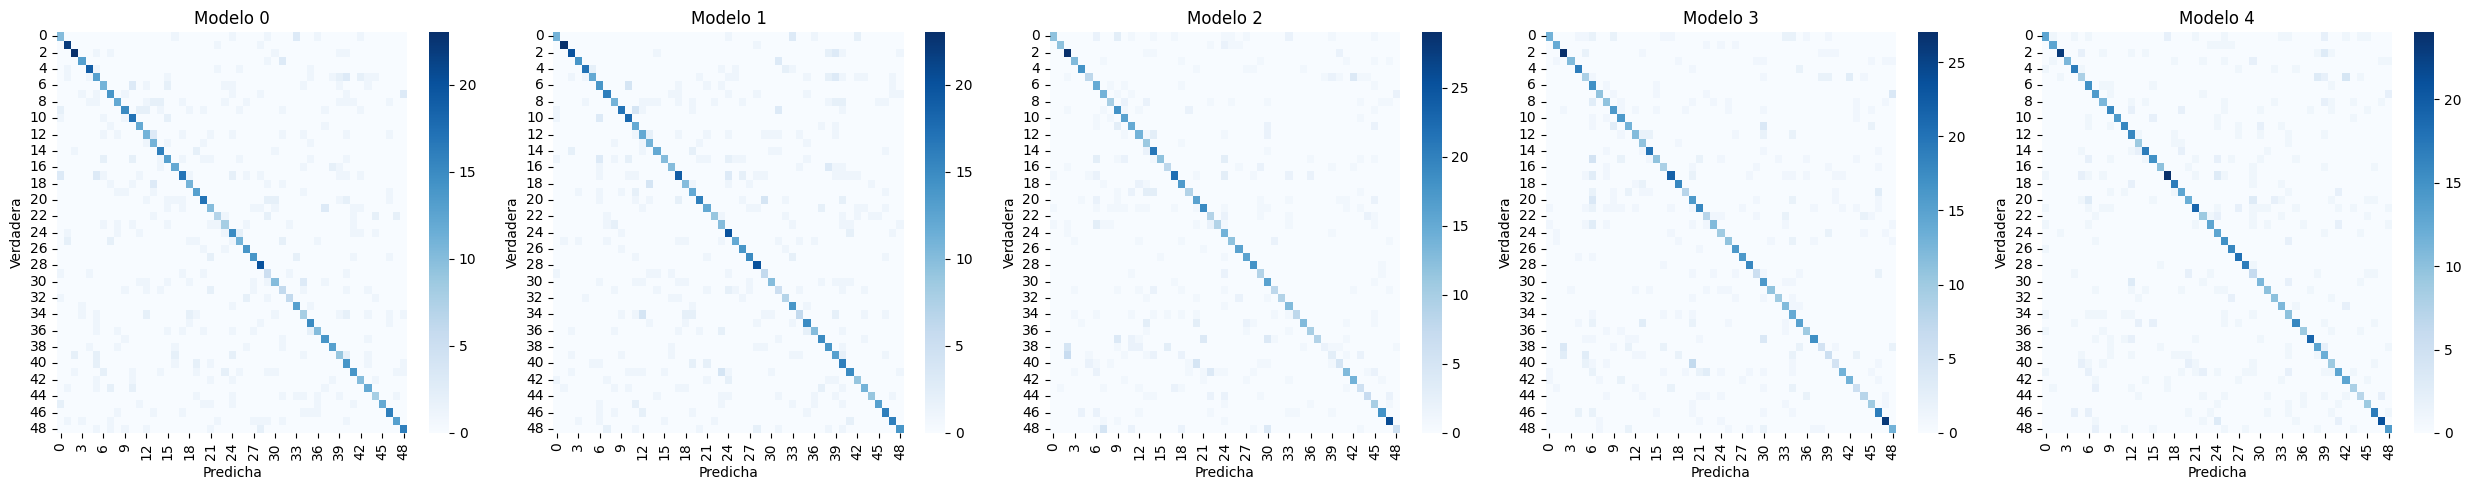

In [9]:
from src.visualization import comparar_modelos
# NumPy: ya está en one-hot
X_test_np = X_test.T
y_test_np = y_test  # ya está one-hot (shape: (49, n_samples))

# Convertir one-hot a etiquetas (porque TorchNeuralNet espera clases enteras)
X_testpy = torch.from_numpy(X_testpy).float()  # Convierte a tensor de tipo float32
y_testpy = torch.from_numpy(y_testpy).long()   # Convierte a tensor de enteros largos (para etiquetas)

# Comparar
comparar_modelos(
    (m0, m1),
    (model2, model3, model4),
    (X_train, y_train, X_test_np, y_test_np),
    (X_trainpy, y_trainpy, X_testpy, y_testpy)
)


Al comparar el desempeño de los cinco modelos, observamos que `M1`, `M2` y `M3` presentan **resultados muy similares en accuracy de test**, con diferencias mínimas. `M1` muestra una leve ventaja en entrenamiento, aunque las métricas finales de generalización son prácticamente equivalentes entre los tres.

En términos de loss, `M0` y `M4` evidencian un **claro sobreajuste**, con pérdidas de entrenamiento muy bajas pero un desempeño deficiente sobre el conjunto de test. Por otro lado, `M1`, `M2` y `M3` muestran **loss de test similares y razonablemente bajos**, lo que refuerza su solidez como modelos generalizadores.

Si bien tanto `M0` como `M4` alcanzan una precisión casi perfecta sobre entrenamiento, su **matrices de confusión** es distinta, lo que nos dice que si bien se modelan a la perfeccion sobre el train, el modelo no es identico.

Adicionalmente, las **matrices de confusión** de `M2` y `M3` fueron muy parecidas, lo que sugiere que están cometiendo errores en patrones similares, a pesar de sus diferencias arquitectónicas.

A partir de este análisis, seleccionaremos el modelo considerado como el mejor para **predecir las probabilidades a posteriori de cada clase** sobre el conjunto `X_COMP.npy`, y generar el archivo `Bianchi_Martin_predicciones.csv` con dichas predicciones.

El archivo deberá contener **una fila por muestra**, con las columnas representando las **probabilidades a posteriori de cada clase**.

In [11]:
import pandas as pd

X_COMP = np.load("Data/X_COMP.npy")
X_COMP_norm = X_COMP / 255

X_COMP_T = X_COMP_norm.T
Y_COMP_hat = m1.forward(X_COMP_T)
Y_COMP_probs_np = Y_COMP_hat.T

df_np = pd.DataFrame(Y_COMP_probs_np, columns=[f"Clase_{i}" for i in range(49)])
df_np.to_csv("Bianchi_Martin_predicciones.csv", index=False)